In [129]:
import pandas as pd
import torch

In [130]:
data = pd.read_csv("./data/x_data.csv")

In [131]:
labels = pd.read_csv("./data/y_data.csv")

In [132]:
data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V14691,V14692,V14693,V14694,V14695,V14696,V14697,V14698,V14699,V14700
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [133]:
labels.head()

,a band,acrosome,acrosome inner membrane,acrosome membrane,acrosome outer membrane,adherens junction,apical cell membrane,apicolateral cell membrane,autolysosome,autolysosome membrane,...,trans-golgi network,trans-golgi network membrane,uropodium,vacuole,vesicle,virion,z line,zymogen granule,zymogen granule lumen,zymogen granule membrane
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [134]:
all_x = torch.tensor(data.values)

In [135]:
print(all_x.shape)

torch.Size([5998, 14700])


In [136]:
all_y = torch.tensor(labels.values)

In [137]:
print(all_y.shape)

torch.Size([5998, 227])


In [138]:
torch.cuda.is_available()

True

In [139]:
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

dataset = TensorDataset(all_x, all_y)

train_val_split = 0.8

# Set the random seed for reproducibility
seed = 42
torch.manual_seed(seed)

# Split dataset into train and validation sets
train_size = int(train_val_split * len(dataset))  # 80% for training
val_size = len(dataset) - train_size  # remaining 20% for validation
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


In [140]:
import torch.nn.functional as F

class ProteinCNN(nn.Module):
    def __init__(self, num_classes):
        super(ProteinCNN, self).__init__()
        # Conv1d layer with 1 input channel, 64 output channels
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1)
        # Conv1d layer with 64 input channels, 128 output channels
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        # Conv1d layer with 128 input channels, 256 output channels
        self.conv3 = nn.Conv1d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        
        # Max pooling layer to downsample the input
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)  # Reduce sequence length by half
        
        # Dropout layer for regularization
        self.dropout_conv = nn.Dropout(p=0.3)  # Dropout after convolutional layers
        self.dropout_fc = nn.Dropout(p=0.5)    # Dropout after fully connected layers

        # Calculate the output size after pooling
        # The initial sequence length is 14700, and after three pooling layers, the size is reduced by 2^3 = 8
        self.fc1 = nn.Linear(256 * (14700 // 8), 512)  # Input size after pooling (256 channels * 1837.5 length)
        self.fc2 = nn.Linear(512, 256)  # Hidden layer with 256 units
        self.fc3 = nn.Linear(256, num_classes)  # Output layer with num_classes
        
    def forward(self, x):
        # Apply Conv1d -> ReLU -> MaxPool for the first layer
        x = self.pool(F.relu(self.conv1(x)))
        # Apply Conv1d -> ReLU -> MaxPool for the second layer
        x = self.pool(F.relu(self.conv2(x)))
        # Apply Conv1d -> ReLU -> MaxPool for the third layer
        x = self.pool(F.relu(self.conv3(x)))
        
        # Apply dropout after convolutional layers
        x = self.dropout_conv(x)
        
        # Flatten the tensor to feed into the fully connected layers
        x = x.view(x.size(0), -1)  # Flatten the tensor for the fully connected layer
        
        # Apply fully connected layer 1 with ReLU activation
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)  # Apply dropout after the first FC layer
        
        # Apply fully connected layer 2 with ReLU activation
        x = F.relu(self.fc2(x))
        x = self.dropout_fc(x)  # Apply dropout after the second FC layer
        
        # Apply the final fully connected layer (output)
        x = self.fc3(x)
        
        return x


In [141]:
seq_length = all_x.shape[1]
input_channels = 1
num_classes = all_y.shape[1]

In [142]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ProteinCNN(num_classes).to(device)

# Define Cross-Entropy Loss (doesn't need softmax in the model)
criterion = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
num_epochs = 200

In [143]:
import matplotlib.pyplot as plt
# Plotting function
def plot_training_results(train_losses, val_losses, train_accuracies, val_accuracies):
    # Create subplots for losses and accuracies
    plt.figure(figsize=(12, 6))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and Validation Loss")

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Training Accuracy")
    plt.plot(val_accuracies, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Training and Validation Accuracy")

    # Show the plots
    plt.tight_layout()
    plt.show()


100%|██████████| 75/75 [01:43<00:00,  1.38s/it]


Epoch 1/200 - Time: 108.07s - Train Loss: 9.9035, Train Acc: 0.8185 - Val Loss: 8.8423, Val Acc: 0.8737


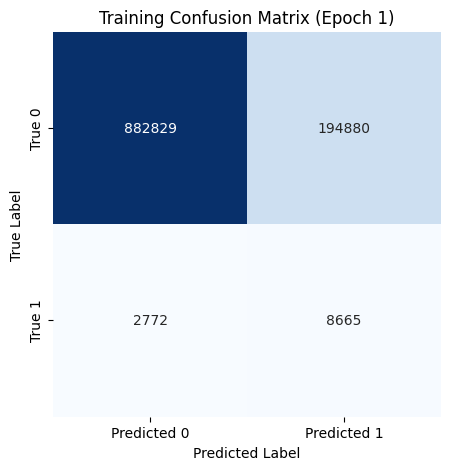

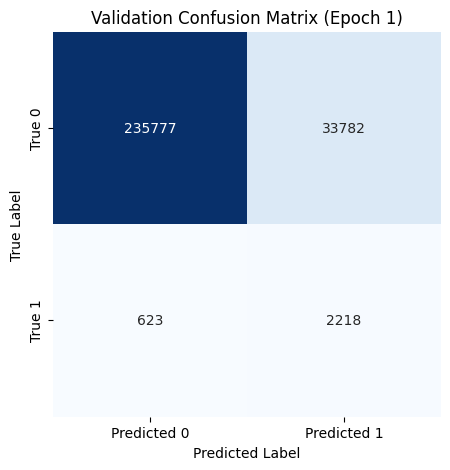

100%|██████████| 75/75 [01:51<00:00,  1.49s/it]


Epoch 2/200 - Time: 117.35s - Train Loss: 9.1697, Train Acc: 0.8646 - Val Loss: 8.8262, Val Acc: 0.8651


100%|██████████| 75/75 [01:40<00:00,  1.34s/it]


Epoch 3/200 - Time: 105.99s - Train Loss: 9.1361, Train Acc: 0.8607 - Val Loss: 8.8233, Val Acc: 0.8608


100%|██████████| 75/75 [01:49<00:00,  1.45s/it]


...

Epoch 198/200 - Time: 119.25s - Train Loss: 8.9861, Train Acc: 0.5555 - Val Loss: 8.8253, Val Acc: 0.5644


100%|██████████| 75/75 [01:48<00:00,  1.44s/it]


Epoch 199/200 - Time: 114.14s - Train Loss: 8.9874, Train Acc: 0.5573 - Val Loss: 8.8204, Val Acc: 0.5644


100%|██████████| 75/75 [01:49<00:00,  1.46s/it]


Epoch 200/200 - Time: 114.85s - Train Loss: 8.9775, Train Acc: 0.5490 - Val Loss: 8.8199, Val Acc: 0.5600


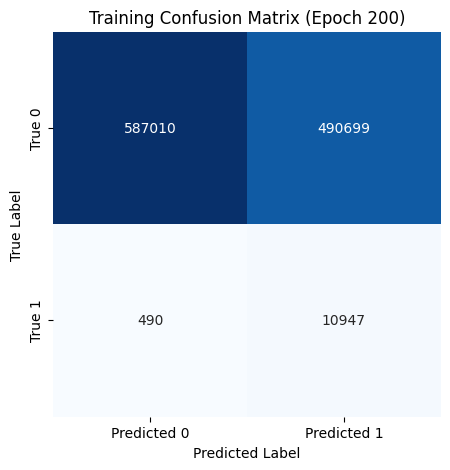

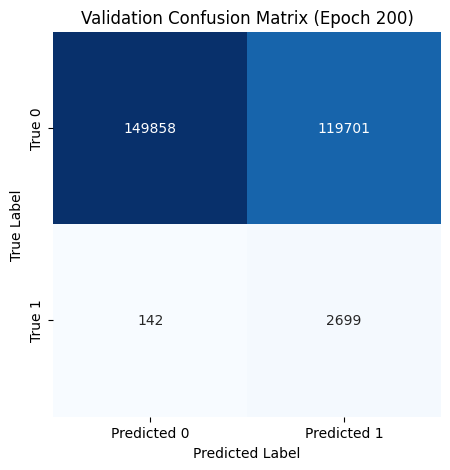

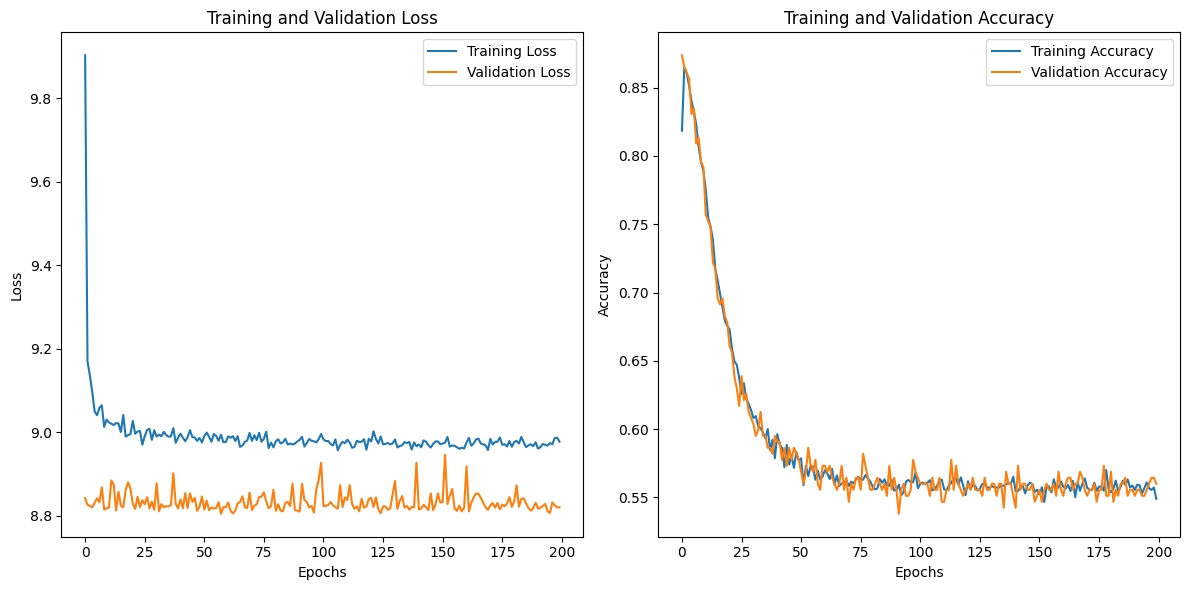

In [144]:
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Initialize lists to store epoch losses and accuracies
train_epoch_losses, val_epoch_losses = [], []
train_epoch_accuracies, val_epoch_accuracies = [], []

# Confusion matrix plot function
def plot_confusion_matrix_binary(y_true, y_pred, title='Confusion Matrix'):
    """
    Plots a binary confusion matrix with TN, FP, FN, TP counts.
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=['Predicted 0', 'Predicted 1'], 
                yticklabels=['True 0', 'True 1'])
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    train_losses, correct_train, total_train = 0, 0, 0
    y_true_train, y_pred_train = [], []  # Collect true and predicted values for confusion matrix
    
    # Start epoch timer
    start_time = time.time()

    # Training Loop
    with tqdm(total=len(train_loader), desc=f'', position=0, leave=True) as pbar_train:
        for x, y in train_loader: 
            x, y = x.float().to(device), y.float().to(device)
            x = x.unsqueeze(1)  # Add channel dimension for Conv1d

            optimiser.zero_grad()
            y_pred = model(x)
            loss = criterion(y_pred, y)
            loss.backward()
            optimiser.step()

            train_losses += loss.item() * x.size(0)

            # Collect true and predicted values for confusion matrix
            y_true_train.extend(y.cpu().numpy().flatten())
            y_pred_train.extend((torch.sigmoid(y_pred) > 0.5).cpu().numpy().flatten())

            predictions = torch.sigmoid(y_pred) > 0.5  # Convert logits to binary predictions
            correct_train += (predictions == y).sum().item()
            total_train += y.numel()
            pbar_train.update(1)  # Move progress bar forward by 1 step

    # Calculate average training loss and accuracy
    train_epoch_loss = train_losses / len(train_loader.dataset)
    train_epoch_accuracy = correct_train / total_train
    train_epoch_losses.append(train_epoch_loss)
    train_epoch_accuracies.append(train_epoch_accuracy)

    # Validation Loop
    model.eval()
    val_losses, correct_val, total_val = 0, 0, 0
    y_true_val, y_pred_val = [], []  # Collect true and predicted values for confusion matrix
    
    with torch.no_grad():
        for x, y in val_loader: 
            x, y = x.float().to(device), y.float().to(device)
            x = x.unsqueeze(1)

            y_pred = model(x)
            loss = criterion(y_pred, y)
            val_losses += loss.item() * x.size(0)

            # Collect true and predicted values for confusion matrix
            y_true_val.extend(y.cpu().numpy().flatten())
            y_pred_val.extend((torch.sigmoid(y_pred) > 0.5).cpu().numpy().flatten())

            predictions = torch.sigmoid(y_pred) > 0.5
            correct_val += (predictions == y).sum().item()
            total_val += y.numel()

    # Calculate average validation loss and accuracy
    val_epoch_loss = val_losses / len(val_loader.dataset)
    val_epoch_accuracy = correct_val / total_val
    val_epoch_losses.append(val_epoch_loss)
    val_epoch_accuracies.append(val_epoch_accuracy)

    # End epoch timer
    elapsed_time = time.time() - start_time

    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs} - Time: {elapsed_time:.2f}s - "
          f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.4f} - "
          f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.4f}")

    # Plot confusion matrix after the first and last epoch
    if epoch == 0 or epoch == num_epochs - 1:
        # Plot training confusion matrix
        plot_confusion_matrix_binary(np.array(y_true_train).astype(int), 
                                     np.array(y_pred_train).astype(int), 
                                     title=f"Training Confusion Matrix (Epoch {epoch+1})")

        # Plot validation confusion matrix
        plot_confusion_matrix_binary(np.array(y_true_val).astype(int), 
                                     np.array(y_pred_val).astype(int), 
                                     title=f"Validation Confusion Matrix (Epoch {epoch+1})")

# Plot the training and validation results
plot_training_results(train_epoch_losses, val_epoch_losses, train_epoch_accuracies, val_epoch_accuracies)
